In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # allows PIL to read slightly corrupted images


In [3]:
import torch, torch.backends.cudnn as cudnn

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Speed up convs for fixed input size (224x224)
cudnn.benchmark = True

# Optional: slightly faster matmul on newer GPUs (safe on T4)
torch.set_float32_matmul_precision("high")


Device: cuda


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [4]:
import os
import shutil

BASE_DIR = "/content/drive/MyDrive/skin cancer project"

PART1 = os.path.join(BASE_DIR, "HAM10000_images_part_1")
PART2 = os.path.join(BASE_DIR, "HAM10000_images_part_2")
ALL_IMAGES = os.path.join(BASE_DIR, "HAM10000_images_all")

os.makedirs(ALL_IMAGES, exist_ok=True)

# copy part_1
for fname in os.listdir(PART1):
    src = os.path.join(PART1, fname)
    dst = os.path.join(ALL_IMAGES, fname)
    if os.path.isfile(src) and not os.path.exists(dst):
        shutil.copy(src, dst)

# copy part_2
for fname in os.listdir(PART2):
    src = os.path.join(PART2, fname)
    dst = os.path.join(ALL_IMAGES, fname)
    if os.path.isfile(src) and not os.path.exists(dst):
        shutil.copy(src, dst)

print("Done combining.")
print("Total images in HAM10000_images_all:", len(os.listdir(ALL_IMAGES)))


Done combining.
Total images in HAM10000_images_all: 10015


Extra imports & paths for preprocessing

In [5]:
# EXTRA IMPORTS FOR PREPROCESSING

import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# folder that already contains 10,015 images
IMG_DIR = ALL_IMAGES

# metadata CSV path – change the filename if yours is different
META_CSV = os.path.join(BASE_DIR, "HAM10000_metadata.csv")


Load metadata & match images

In [6]:
# LOAD METADATA AND ATTACH IMAGE PATHS

df = pd.read_csv(META_CSV)
print("Columns:", df.columns.tolist())
print("Total rows in CSV:", len(df))

# HAM10000: image_id + ".jpg"
df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(IMG_DIR, x + ".jpg")
)

# keep only rows that have an actual file
df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)
print("Rows with existing images:", len(df))

df.head()


Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
Total rows in CSV: 10015
Rows with existing images: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/skin cancer project/HAM...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/skin cancer project/HAM...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/skin cancer project/HAM...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/skin cancer project/HAM...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/skin cancer project/HAM...


Encode labels & split (train / val / test)

In [7]:
# ENCODE LESION LABELS (dx) AND SPLIT DATA

lesion_types = sorted(df["dx"].unique())
class_to_idx = {c: i for i, c in enumerate(lesion_types)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label"] = df["dx"].map(class_to_idx)

print("Class mapping:", class_to_idx)

# 70% train, 20% val, 10% test (stratified)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.3333,  # ≈ 10% of total
    stratify=temp_df["label"],
    random_state=42,
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))


Class mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Train size: 7010
Val size: 2003
Test size: 1002


Normalization, augmentation, resizing

In [8]:
# DATA PREPROCESSING: RESIZING + AUGMENTATION + NORMALIZATION + ColorJitter +RandomResizedCrop

from torchvision import transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),      # zoom/crop
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])



Dataset

In [9]:
# CUSTOM DATASET
# robust dataset
class SkinCancerDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = row["label"]
        try:
            img = Image.open(img_path).convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
            return img, label
        except Exception as e:
            # log once so you can see which file failed
            print(f"[WARN] Failed on {img_path}: {e}")
            return None  # will be dropped by safe_collate






(Optional) DataLoader tweaks for GPU

In [10]:
# PART 6 (final speed settings): DataLoaders for GPU training
from torch.utils.data import DataLoader
import torch

DEBUG = False   # <- turn off debug now

def safe_collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch:
        return torch.empty(0), torch.empty(0, dtype=torch.long)
    imgs, labels = zip(*batch)
    return torch.stack(imgs), torch.tensor(labels)

# Faster settings for Colab GPU
nw = 2          # num_workers
pm = True       # pin_memory
pw = False      # persistent_workers can be flaky on Colab; keep False

batch_size = 32  # or whatever you used before

train_dataset = SkinCancerDataset(train_df, transform=train_transforms)
val_dataset   = SkinCancerDataset(val_df,   transform=val_test_transforms)
test_dataset  = SkinCancerDataset(test_df,  transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=nw, pin_memory=pm, persistent_workers=pw,
                          collate_fn=safe_collate)

val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=nw, pin_memory=pm, persistent_workers=pw,
                          collate_fn=safe_collate)

test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=nw, pin_memory=pm, persistent_workers=pw,
                          collate_fn=safe_collate)

print("Loaders ready → workers:", nw, "| pin_memory:", pm)


Loaders ready → workers: 2 | pin_memory: True


Optional quick sanity check

In [11]:
# Pull one small batch to confirm everything is fine
xb, yb = next(iter(train_loader))
print("Batch:", xb.shape, yb.shape)


Batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


Setup (device, class weights, label smoothing)

In [12]:
# device, class weights, loss

import torch
import numpy as np
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Class weights from TRAIN SPLIT (helps with imbalance)
train_counts = train_df["label"].value_counts().sort_index().values
class_weights = 1.0 / np.maximum(train_counts, 1)
class_weights = class_weights / class_weights.sum()  # optional normalization
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

num_classes = len(class_weights)
print("Num classes:", num_classes)
print("Class weights:", class_weights)

# Loss with class weights + label smoothing (stabilizes training)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=0.05)


Device: cuda
Num classes: 7
Class weights: [0.13482622 0.08576446 0.04014981 0.38117536 0.03963441 0.00657899
 0.31187075]


Baseline ResNet50 (ImageNet) + AdamW + Cosine schedule

In [13]:
# baseline ResNet50 + AdamW + cosine LR

import torchvision.models as models
import torch.nn as nn

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Replace final FC for 7 classes
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

# Optimizer & scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
num_epochs = 20  # was 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 229MB/s]


Train & validate loops (AMP for speed)

In [14]:
# train/validate with safe AMP & scaler usage for GPU/CPU

import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import torch
from torch import amp
from contextlib import nullcontext

use_cuda = torch.cuda.is_available()
device_type = "cuda" if use_cuda else "cpu"

# New API: torch.amp.GradScaler('cuda', ...)
# Create a scaler only if we actually have CUDA; otherwise no scaler.
scaler = amp.GradScaler(device_type) if use_cuda else None

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    losses = []
    all_preds = []
    all_labels = []

    # autocast only on GPU; on CPU use no-op context
    autocast_ctx = amp.autocast(device_type) if use_cuda else nullcontext()

    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images = images.to(device, non_blocking=use_cuda)
            labels = labels.to(device, non_blocking=use_cuda)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with autocast_ctx:
                logits = model(images)
                loss = criterion(logits, labels)

            if train:
                if use_cuda:
                    # mixed precision with scaler
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    # standard FP32 on CPU
                    loss.backward()
                    optimizer.step()

            losses.append(loss.item())
            preds = torch.argmax(logits.detach(), dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return np.mean(losses), acc, macro_f1


Full training loop

In [15]:
# Training driver

best_f1 = -1.0
best_path = "/content/best_resnet50_ham10000.pt"

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, train=True)
    val_loss,   val_acc,   val_f1   = run_epoch(model, val_loader,   train=False)

    scheduler.step()

    print(f"Epoch {epoch:02d}/{num_epochs} | "
          f"train: loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f}  |  "
          f"val: loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}")

    # keep the best model (macro-F1 is robust for imbalance)
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), best_path)
        print(f"Saved best model (val macro-F1: {best_f1:.4f}) → {best_path}")

# Load best for testing
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()


Epoch 01/20 | train: loss 1.8973 acc 0.5307 f1 0.3555  |  val: loss 1.6125 acc 0.6590 f1 0.4888
Saved best model (val macro-F1: 0.4888) → /content/best_resnet50_ham10000.pt
Epoch 02/20 | train: loss 1.5204 acc 0.6526 f1 0.5209  |  val: loss 1.4524 acc 0.7329 f1 0.5891
Saved best model (val macro-F1: 0.5891) → /content/best_resnet50_ham10000.pt
Epoch 03/20 | train: loss 1.4149 acc 0.7237 f1 0.5996  |  val: loss 1.4614 acc 0.6645 f1 0.5447
Epoch 04/20 | train: loss 1.3167 acc 0.7472 f1 0.6365  |  val: loss 1.3721 acc 0.7109 f1 0.5929
Saved best model (val macro-F1: 0.5929) → /content/best_resnet50_ham10000.pt
Epoch 05/20 | train: loss 1.2400 acc 0.7575 f1 0.6777  |  val: loss 1.3936 acc 0.8083 f1 0.6640
Saved best model (val macro-F1: 0.6640) → /content/best_resnet50_ham10000.pt
Epoch 06/20 | train: loss 1.2110 acc 0.7926 f1 0.7096  |  val: loss 1.3536 acc 0.7788 f1 0.6829
Saved best model (val macro-F1: 0.6829) → /content/best_resnet50_ham10000.pt
Epoch 07/20 | train: loss 1.1323 acc 0.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Final test evaluation

In [16]:
# test evaluation

test_loss, test_acc, test_f1 = run_epoch(model, test_loader, train=False)
print(f"TEST  | loss {test_loss:.4f}  acc {test_acc:.4f}  macro-F1 {test_f1:.4f}")


TEST  | loss 1.2824  acc 0.8802  macro-F1 0.7862


Test-Time Augmentation (TTA)

In [17]:
# average logits over simple augmentations
import torch
import numpy as np

def tta_predict(model, images, n_transforms=5):
    # define a few deterministic transforms
    flips = [
        lambda x: x,
        lambda x: torch.flip(x, dims=[-1]),  # horizontal
        lambda x: torch.flip(x, dims=[-2]),  # vertical
        lambda x: torch.rot90(x, 1, dims=[-2, -1]),
        lambda x: torch.rot90(x, 3, dims=[-2, -1]),
    ]
    flips = flips[:n_transforms]

    with torch.no_grad():
        logits_sum = 0
        for f in flips:
            aug = f(images)
            logits_sum += model(aug)
        logits = logits_sum / len(flips)
    return logits

def evaluate_with_tta(model, loader, criterion):
    model.eval()
    losses, preds_all, labels_all = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = tta_predict(model, images, n_transforms=5)
            loss = criterion(logits, labels)
            losses.append(loss.item())
            preds_all.append(torch.argmax(logits, dim=1).cpu().numpy())
            labels_all.append(labels.cpu().numpy())
    preds_all = np.concatenate(preds_all)
    labels_all = np.concatenate(labels_all)
    from sklearn.metrics import accuracy_score, f1_score
    acc = accuracy_score(labels_all, preds_all)
    mf1 = f1_score(labels_all, preds_all, average="macro")
    return np.mean(losses), acc, mf1

# (after loading best checkpoint):
test_loss_tta, test_acc_tta, test_mf1_tta = evaluate_with_tta(model, test_loader, criterion)
print(f"TTA TEST | loss {test_loss_tta:.4f}  acc {test_acc_tta:.4f}  macro-F1 {test_mf1_tta:.4f}")


TTA TEST | loss 1.2313  acc 0.8962  macro-F1 0.8314


In [23]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(1)
        all_preds.append(preds.cpu())
        all_labels.append(yb.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# sklearn classification report (nice text + per-class metrics)
print(classification_report(
    all_labels, all_preds,
    target_names=[idx_to_class[i] for i in range(len(idx_to_class))],
    digits=4
))


              precision    recall  f1-score   support

       akiec     0.6579    0.7576    0.7042        33
         bcc     0.7143    0.8824    0.7895        51
         bkl     0.7589    0.7727    0.7658       110
          df     0.6667    0.7273    0.6957        11
         mel     0.6452    0.7143    0.6780       112
          nv     0.9687    0.9210    0.9442       671
        vasc     0.8667    0.9286    0.8966        14

    accuracy                         0.8723      1002
   macro avg     0.7540    0.8148    0.7820      1002
weighted avg     0.8815    0.8723    0.8757      1002



Per-class Accuracy

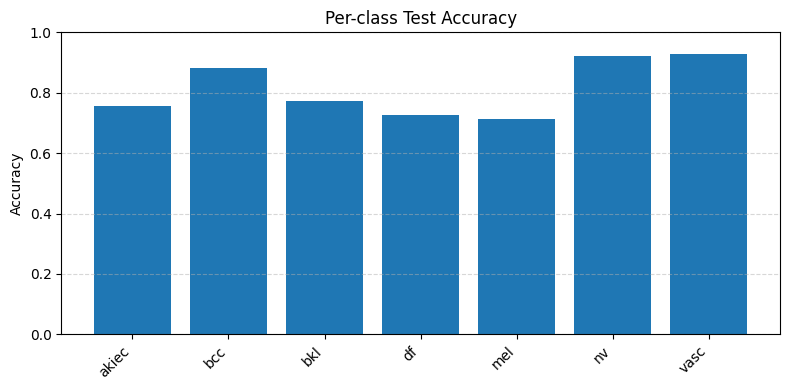

In [24]:
num_classes = len(idx_to_class)
correct_per_class = np.zeros(num_classes)
total_per_class   = np.zeros(num_classes)

for y_true, y_pred in zip(all_labels, all_preds):
    total_per_class[y_true] += 1
    if y_true == y_pred:
        correct_per_class[y_true] += 1

acc_per_class = correct_per_class / (total_per_class + 1e-6)

plt.figure(figsize=(8,4))
plt.bar(range(num_classes), acc_per_class)
plt.xticks(range(num_classes), [idx_to_class[i] for i in range(num_classes)], rotation=45, ha='right')
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Per-class Test Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Confusion matrix

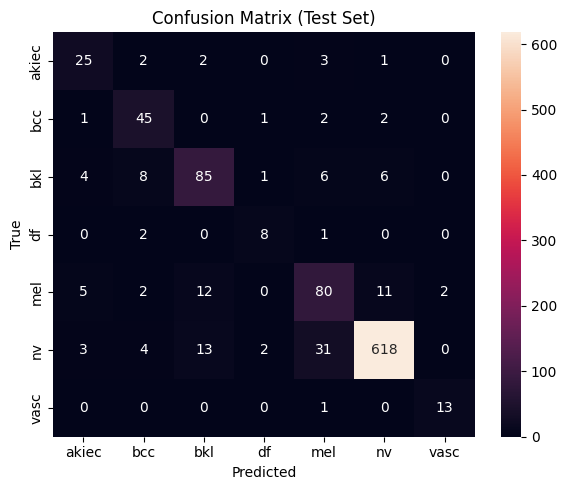

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns   # if you don’t want seaborn, we can do pure matplotlib

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=[idx_to_class[i] for i in range(num_classes)],
            yticklabels=[idx_to_class[i] for i in range(num_classes)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()


SAVE MY MODEL

In [27]:
import os, json, torch, pandas as pd
SAVE_DIR = "/content/drive/MyDrive/skin cancer project/checkpoints"
SPLIT_DIR = "/content/drive/MyDrive/skin cancer project/splits"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

# save full training state (for continue-training)
checkpoint = {
    "epoch": epoch if 'epoch' in globals() else 0,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "best_val_f1": best_f1 if 'best_f1' in globals() else -1,
    "num_classes": num_classes,
    "arch": "resnet50"  # update if you change pooling/etc
}
torch.save(checkpoint, f"{SAVE_DIR}/resnet50_adamw_best.pt")
print("Saved:", f"{SAVE_DIR}/resnet50_adamw_best.pt")

# save splits + label map (so you never resplit again)
train_df.to_csv(f"{SPLIT_DIR}/train.csv", index=False)
val_df.to_csv(f"{SPLIT_DIR}/val.csv", index=False)
test_df.to_csv(f"{SPLIT_DIR}/test.csv", index=False)
with open(f"{SPLIT_DIR}/label_map.json", "w") as f:
    json.dump({"class_to_idx": class_to_idx, "idx_to_class": idx_to_class}, f)
print("Saved splits to:", SPLIT_DIR)

# (optional) minimal weights-only file for quick eval
torch.save(model.state_dict(), f"{SAVE_DIR}/resnet50_adamw_weights_only.pt")


Saved: /content/drive/MyDrive/skin cancer project/checkpoints/resnet50_adamw_best.pt
Saved splits to: /content/drive/MyDrive/skin cancer project/splits


Explainability Module

Load best model checkpoint (eval mode)

In [28]:
# PART 12: load best model (same architecture I trained)
import torchvision.models as models
import torch.nn as nn
import torch

ckpt_path = "/content/best_resnet50_ham10000.pt"

num_classes = len(train_df["label"].unique())

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model = model.to(device)
model.eval()

print("Loaded:", ckpt_path)


Loaded: /content/best_resnet50_ham10000.pt


Grad-CAM (hooks + overlays)

In [29]:
# Grad-CAM utilities
import torch
import numpy as np
import matplotlib.pyplot as plt

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denorm_img(t):
    # t: (3,H,W) tensor in normalized space -> uint8 HxWx3
    x = t.detach().cpu().numpy().transpose(1,2,0)
    x = (x * IMAGENET_STD) + IMAGENET_MEAN
    x = np.clip(x, 0, 1)
    x = (x * 255).astype(np.uint8)
    return x

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        # hooks
        self.fwd = target_layer.register_forward_hook(self._save_activations)
        self.bwd = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, images, class_idx=None):
        """
        images: (B,3,H,W) normalized
        class_idx: int or list of ints or None (use argmax)
        returns: cam heatmaps in [0,1], shape (B,H,W)
        """
        logits = self.model(images)
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
        elif isinstance(class_idx, int):
            class_idx = torch.tensor([class_idx]*images.size(0), device=images.device)

        loss = logits.gather(1, class_idx.view(-1,1)).sum()
        self.model.zero_grad(set_to_none=True)
        loss.backward()

        grads = self.gradients              # (B,C,h,w)
        acts  = self.activations            # (B,C,h,w)
        weights = grads.mean(dim=(2,3), keepdim=True)   # (B,C,1,1)
        cam = (weights * acts).sum(dim=1)               # (B,h,w)
        cam = torch.relu(cam)

        # normalize each CAM to [0,1]
        cams = []
        for i in range(cam.size(0)):
            m = cam[i]
            m = (m - m.min()) / (m.max() - m.min() + 1e-6)
            cams.append(m.unsqueeze(0))
        cams = torch.cat(cams, dim=0)
        return cams, logits

    def close(self):
        self.fwd.remove()
        self.bwd.remove()

# target the last conv block in ResNet50
target_layer = model.layer4[-1].conv3
cam = GradCAM(model, target_layer)

# helper to overlay heatmap on image
def overlay_cam(img_uint8, cam2d, alpha=0.35):
    # img_uint8: HxWx3 (0..255), cam2d: HxW (0..1)
    cm = plt.get_cmap('jet')
    heat = cm(cam2d)[..., :3]  # drop alpha
    heat = (heat * 255).astype(np.uint8)
    overlay = (alpha * heat + (1 - alpha) * img_uint8).astype(np.uint8)
    return overlay


In [30]:
import os
os.makedirs("/content/outputs/gradcam", exist_ok=True)

# take 8 samples from test set
batch = next(iter(test_loader))
imgs, labels = batch
imgs = imgs.to(device)
with torch.no_grad():
    preds = model(imgs).argmax(1)

cams, _ = cam(imgs)  # cams in [0,1] at low res (e.g., 7x7), auto-upsample via imshow

# Save overlays
for i in range(min(8, imgs.size(0))):
    img_uint8 = denorm_img(imgs[i])
    # upsample cam to image size
    cam_up = torch.nn.functional.interpolate(
        cams[i].unsqueeze(0).unsqueeze(0),
        size=img_uint8.shape[:2],
        mode='bilinear',
        align_corners=False
    ).squeeze().cpu().numpy()

    overlay = overlay_cam(img_uint8, cam_up, alpha=0.40)

    plt.figure(figsize=(7,3))
    plt.subplot(1,3,1); plt.title(f"Image (gt={idx_to_class[labels[i].item()]})"); plt.axis('off'); plt.imshow(img_uint8)
    plt.subplot(1,3,2); plt.title(f"Grad-CAM heatmap"); plt.axis('off'); plt.imshow(cam_up, cmap='jet')
    plt.subplot(1,3,3); plt.title(f"Overlay (pred={idx_to_class[preds[i].item()]})"); plt.axis('off'); plt.imshow(overlay)
    out_path = f"/content/outputs/gradcam/sample_{i}.png"
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.close()

print("Saved Grad-CAM examples to /content/outputs/gradcam")


Saved Grad-CAM examples to /content/outputs/gradcam


a few images (quick check)

Found: 8


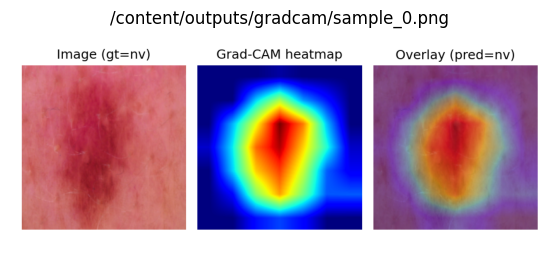

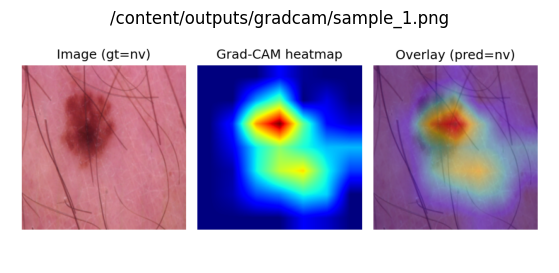

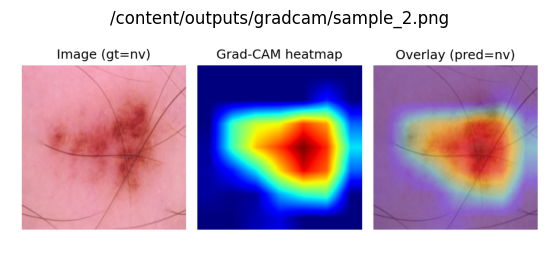

In [31]:
import glob, matplotlib.pyplot as plt, matplotlib.image as mpimg

paths = sorted(glob.glob("/content/outputs/gradcam/sample_*.png"))
print("Found:", len(paths))
for p in paths[:3]:
    img = mpimg.imread(p)
    plt.figure(figsize=(7,3)); plt.imshow(img); plt.axis("off"); plt.title(p); plt.show()


Copy to Drive so they persist

In [32]:
import os, shutil, glob
drive_dir = "/content/drive/MyDrive/skin cancer project/outputs/gradcam"
os.makedirs(drive_dir, exist_ok=True)
for p in glob.glob("/content/outputs/gradcam/*.png"):
    shutil.copy(p, drive_dir)
print("Copied to:", drive_dir)


Copied to: /content/drive/MyDrive/skin cancer project/outputs/gradcam


Make per-class and misclassified Grad-CAMs

A) First correct example per class

In [33]:
import torch, torch.nn.functional as F, os
pc_dir = "/content/outputs/gradcam/per_class"; os.makedirs(pc_dir, exist_ok=True)
picked = {}
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device); yb = yb.to(device)
        pr = model(xb).argmax(1)
        for j in range(len(yb)):
            y, p = int(yb[j]), int(pr[j])
            if y == p and y not in picked:
                picked[y] = xb[j].cpu()
        if len(picked) == len(idx_to_class): break

for y, img_t in picked.items():
    img = img_t.unsqueeze(0).to(device)
    cams, _ = cam(img)
    cam_up = F.interpolate(cams[0][None, None], size=img_t.shape[1:], mode="bilinear", align_corners=False).squeeze().cpu().numpy()
    base = denorm_img(img_t)
    overlay = overlay_cam(base, cam_up, alpha=0.40)
    plt.imsave(f"{pc_dir}/{idx_to_class[y]}.png", overlay)
print("Saved per-class overlays →", pc_dir)


Saved per-class overlays → /content/outputs/gradcam/per_class


B) Misclassified examples

In [34]:
mis_dir = "/content/outputs/gradcam/miscls"; os.makedirs(mis_dir, exist_ok=True)
wrong = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device); yb = yb.to(device)
        pr = model(xb).argmax(1)
        bad = (pr != yb).nonzero(as_tuple=False).view(-1)
        for j in bad.tolist():
            wrong.append((xb[j].cpu(), int(yb[j].cpu()), int(pr[j].cpu())))
        if len(wrong) >= 8: break

for i,(img_t, y, p) in enumerate(wrong[:8]):
    img = img_t.unsqueeze(0).to(device)
    cams, _ = cam(img)
    cam_up = F.interpolate(cams[0][None, None], size=img_t.shape[1:], mode="bilinear", align_corners=False).squeeze().cpu().numpy()
    base = denorm_img(img_t)
    overlay = overlay_cam(base, cam_up, alpha=0.40)
    plt.imsave(f"{mis_dir}/mis_{i}_gt-{idx_to_class[y]}_pred-{idx_to_class[p]}.png", overlay)
print("Saved misclassified overlays →", mis_dir)


Saved misclassified overlays → /content/outputs/gradcam/miscls


Integrated Gradients (IG)

Install & import Captum


In [36]:
# imports + initialize Integrated Gradients
!pip -q install captum

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os

from captum.attr import IntegratedGradients

model.eval()
ig = IntegratedGradients(model)  # IG explainer for our ResNet model


Collect some misclassified samples

In [38]:
# collect up to 8 misclassified test images
wrong = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(1)
        bad_idx = (preds != yb).nonzero(as_tuple=False).view(-1)

        for j in bad_idx.tolist():
            # store CPU tensor + int labels
            wrong.append((xb[j].cpu(), int(yb[j].cpu()), int(preds[j].cpu())))
        if len(wrong) >= 8:
            break

print(f"Collected {len(wrong)} misclassified examples.")


Collected 9 misclassified examples.


Generate IG overlays for misclassified cases

In [40]:
# generate and save IG overlays for misclassified images
ig_mis_dir = "/content/outputs/ig/miscls"
os.makedirs(ig_mis_dir, exist_ok=True)

for i, (img_t, y, p) in enumerate(wrong[:8]):
    # img_t: (3,H,W) on CPU
    img = img_t.unsqueeze(0).to(device)           # (1,3,H,W)
    baseline = torch.zeros_like(img).to(device)   # black baseline

    img.requires_grad_(True)

    # Integrated Gradients attribution for the *predicted* class p
    attr = ig.attribute(
        img,
        baselines=baseline,
        target=p,
        n_steps=50,               # more steps = smoother but slower; 50 is a good tradeoff
        internal_batch_size=10
    )  # (1,3,H,W)

    # Convert to numpy
    a = attr[0].detach().cpu().numpy()   # (3,H,W)

    # Aggregate channels → signed map then keep positive part
    a_signed = a.mean(axis=0)           # (H,W)
    pos = np.maximum(a_signed, 0.0)
    if pos.max() > 0:
        pos = pos / (pos.max() + 1e-6)  # normalize to [0,1]
    else:
        pos = np.zeros_like(pos)

    # Base RGB image & overlay (same overlay_cam as Grad-CAM)
    base_uint8 = denorm_img(img_t)      # HxWx3 uint8
    overlay = overlay_cam(base_uint8, pos, alpha=0.40)

    out_path = f"{ig_mis_dir}/ig_mis_{i}_gt-{idx_to_class[y]}_pred-{idx_to_class[p]}.png"
    plt.imsave(out_path, overlay)
    plt.close()

print("Saved IG misclassified overlays →", ig_mis_dir)


Saved IG misclassified overlays → /content/outputs/ig/miscls


Show a 3-panel figure in notebook

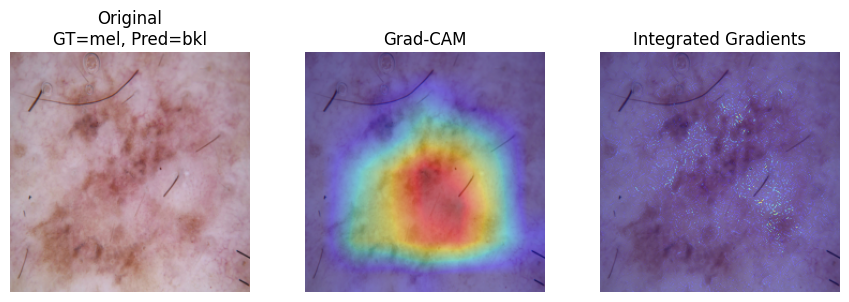

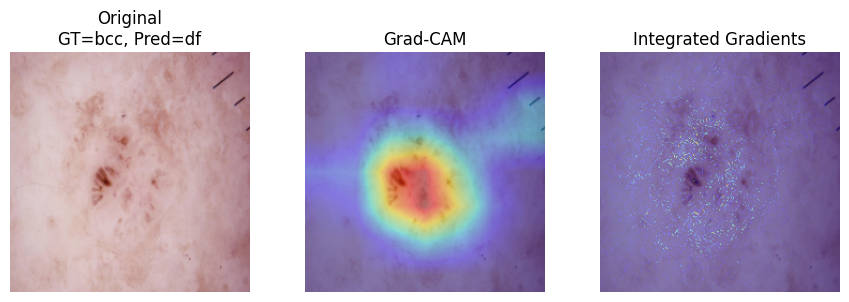

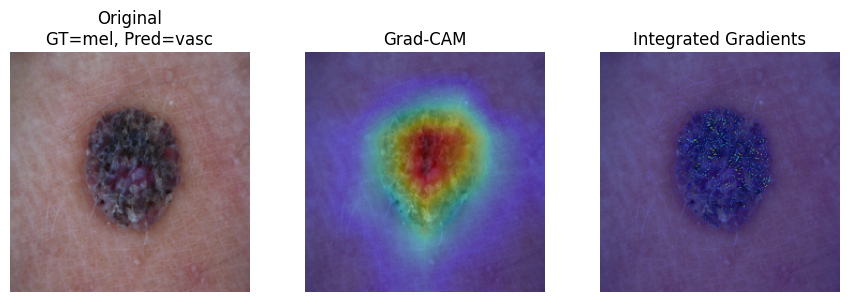

In [41]:
import glob
import matplotlib.image as mpimg

gc_dir = "/content/outputs/gradcam/miscls"
ig_dir = "/content/outputs/ig/miscls"

gc_paths = sorted(glob.glob(f"{gc_dir}/mis_*.png"))
ig_paths = sorted(glob.glob(f"{ig_dir}/ig_mis_*.png"))

# Show up to 3 pairs
k = min(3, len(gc_paths), len(ig_paths))

for i in range(k):
    img_t, y, p = wrong[i]
    base = to_float01(img_t)

    gc_img = mpimg.imread(gc_paths[i])
    ig_img = mpimg.imread(ig_paths[i])

    plt.figure(figsize=(9,3))
    plt.subplot(1,3,1); plt.title(f"Original\nGT={idx_to_class[y]}, Pred={idx_to_class[p]}")
    plt.axis('off'); plt.imshow(base)
    plt.subplot(1,3,2); plt.title("Grad-CAM"); plt.axis('off'); plt.imshow(gc_img)
    plt.subplot(1,3,3); plt.title("Integrated Gradients"); plt.axis('off'); plt.imshow(ig_img)
    plt.tight_layout()
    plt.show()


SHAP

Imports & model eval

In [45]:
import shap
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Helper: tensor → float image [0,1]

In [46]:
def tensor_to_img01(t3hw):
    """
    t3hw: torch tensor (3,H,W), normalized
    returns: float32 (H,W,3) in [0,1]
    """
    return (denorm_img(t3hw) / 255.0).astype(np.float32)


Build background + images to explain

In [47]:
# --- background images (for SHAP masker) ---
bg_imgs = []
for xb, yb in train_loader:
    for i in range(min(5, xb.size(0))):   # 5 background samples
        bg_imgs.append(tensor_to_img01(xb[i].cpu()))
    break

X_background = np.stack(bg_imgs)  # (B, H, W, 3)
print("Background:", X_background.shape)

# --- images to explain (from test set) ---
expl_imgs = []
expl_labels = []

for xb, yb in test_loader:
    for i in range(min(5, xb.size(0))):   # explain first 5 test images
        expl_imgs.append(tensor_to_img01(xb[i].cpu()))
        expl_labels.append(int(yb[i].cpu()))
    break

X_explain = np.stack(expl_imgs)  # (N, H, W, 3)
expl_labels = np.array(expl_labels)
print("Explain:", X_explain.shape)


Background: (5, 224, 224, 3)
Explain: (5, 224, 224, 3)


Define model_forward for SHAP

In [48]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).reshape(1,3,1,1).to(device)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).reshape(1,3,1,1).to(device)

def model_forward(x_numpy):
    """
    x_numpy: (N, H, W, 3) float32 in [0,1]
    returns: (N, num_classes) probabilities
    """
    x = torch.from_numpy(x_numpy).permute(0,3,1,2).to(device)  # -> (N,3,H,W)
    x = (x - IMAGENET_MEAN) / IMAGENET_STD

    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)
    return probs.cpu().numpy()


Create SHAP masker + explainer

In [49]:
# image masker: inpaint masked regions
masker = shap.maskers.Image("inpaint_telea", X_background[0].shape)

class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

explainer = shap.Explainer(
    model_forward,
    masker,
    output_names=class_names
)


Compute SHAP values

In [50]:
shap_values = explainer(X_explain)  # unified API
# shap_values.values shape: (N, H, W, 3, num_classes)
print("SHAP values array shape:", np.array(shap_values.values).shape)


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  20%|██        | 1/5 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 3/5 [01:04<00:30, 15.24s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 5/5 [02:03<00:00, 24.54s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [02:34, 30.80s/it]

SHAP values array shape: (5, 224, 224, 3, 7)


Save SHAP overlays

In [51]:
# predicted class for each explained image
pred_probs = model_forward(X_explain)      # (N, num_classes)
pred_idx = np.argmax(pred_probs, axis=1)   # (N,)

out_dir = "/content/outputs/shap_img"
os.makedirs(out_dir, exist_ok=True)

for i in range(len(X_explain)):
    base = (X_explain[i] * 255).astype(np.uint8)      # H,W,3 RGB

    # shap_values.values: (N, H, W, 3, num_classes)
    shap_map = shap_values.values[i, ..., pred_idx[i]]  # (H,W,3)

    # aggregate channels, take absolute contribution
    shap_gray = shap_map.mean(axis=-1)                # (H,W)
    shap_abs = np.abs(shap_gray)
    if shap_abs.max() > 0:
        shap_norm = shap_abs / (shap_abs.max() + 1e-6)
    else:
        shap_norm = shap_abs

    heat = cv2.applyColorMap((shap_norm*255).astype(np.uint8), cv2.COLORMAP_JET)
    # cv2 expects BGR; base is RGB → convert to BGR first
    base_bgr = cv2.cvtColor(base, cv2.COLOR_RGB2BGR)
    overlay = cv2.addWeighted(base_bgr, 0.6, heat, 0.4, 0)

    gt = idx_to_class[int(expl_labels[i])]
    pred = class_names[int(pred_idx[i])]
    fname = f"shap_{i}_gt-{gt}_pred-{pred}.png"
    cv2.imwrite(os.path.join(out_dir, fname), overlay)

print("Saved SHAP overlays →", out_dir)


Saved SHAP overlays → /content/outputs/shap_img


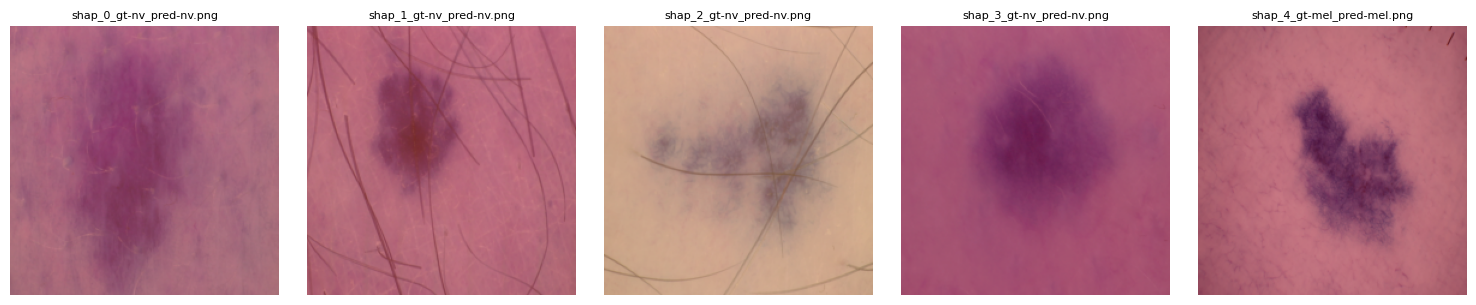

In [56]:
import glob
from matplotlib.image import imread

paths = sorted(glob.glob(f"{out_dir}/shap_*.png"))[:len(X_explain)]

plt.figure(figsize=(3*len(paths), 3))
for i,p in enumerate(paths):
    img = imread(p)
    plt.subplot(1, len(paths), i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(os.path.basename(p), fontsize=8)
plt.tight_layout()
plt.show()


In [59]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch.nn.functional as F

compare_dir = "/content/outputs/xai_compare"
os.makedirs(compare_dir, exist_ok=True)

def create_xai_comparison(img_t, label, pred, idx):
    """
    img_t: (3,H,W) tensor normalized
    label: int (true label)
    pred: int (predicted label)
    idx: number for naming
    """

    # ========== ORIGINAL IMAGE ==========
    orig = denorm_img(img_t)  # uint8 HxWx3

    # ========== GRAD-CAM ==========
    img_input = img_t.unsqueeze(0).to(device)
    cams, _ = cam(img_input)  # (1,7,7)
    cam_up = F.interpolate(
        cams[0].unsqueeze(0).unsqueeze(0),
        size=img_t.shape[1:], mode="bilinear",
        align_corners=False).squeeze().cpu().numpy()
    gradcam_overlay = overlay_cam(orig, cam_up, alpha=0.4)

    # ========== INTEGRATED GRADIENTS ==========
    img_input.requires_grad_(True)
    ig_attr = ig.attribute(img_input, target=pred, n_steps=50)
    ig_attr = ig_attr.squeeze(0).detach().cpu().numpy()
    ig_attr = np.mean(np.abs(ig_attr), axis=0)
    ig_attr /= (ig_attr.max() + 1e-6)
    ig_heat = cv2.applyColorMap((ig_attr*255).astype(np.uint8), cv2.COLORMAP_JET)
    ig_overlay = cv2.addWeighted(cv2.cvtColor(orig, cv2.COLOR_RGB2BGR), 0.6, ig_heat, 0.4, 0)
    ig_overlay = cv2.cvtColor(ig_overlay, cv2.COLOR_BGR2RGB)

    # ========== SHAP ==========
    img_np = (orig / 255.0).astype(np.float32)
    shap_vals = explainer(img_np[np.newaxis, ...])
    shap_map = shap_vals.values[0, ..., pred]  # (H,W,3)
    shap_attr = np.abs(shap_map).mean(axis=-1)
    shap_attr /= (shap_attr.max() + 1e-6)
    shap_heat = cv2.applyColorMap((shap_attr*255).astype(np.uint8), cv2.COLORMAP_JET)
    shap_overlay = cv2.addWeighted(cv2.cvtColor(orig, cv2.COLOR_RGB2BGR), 0.6, shap_heat, 0.4, 0)
    shap_overlay = cv2.cvtColor(shap_overlay, cv2.COLOR_BGR2RGB)

    # ========== BUILD FIGURE ==========
    plt.figure(figsize=(14,4))

    plt.subplot(1,4,1)
    plt.imshow(orig)
    plt.title(f"Original\nGT={idx_to_class[label]}")
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(gradcam_overlay)
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(ig_overlay)
    plt.title("Integrated Gradients")
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.imshow(shap_overlay)
    plt.title("SHAP")
    plt.axis('off')

    out_path = f"{compare_dir}/xai_compare_{idx}_gt-{idx_to_class[label]}_pred-{idx_to_class[pred]}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

    print("Saved:", out_path)


In [61]:
import numpy as np

def denorm_img(t):
    """
    t: (3,H,W) tensor normalized with ImageNet mean/std
    returns: uint8 HxWx3 in RGB
    """
    # t -> numpy (H,W,3)
    x = t.detach().cpu().numpy().transpose(1, 2, 0)   # (H,W,3)

    # IMAGENET_MEAN and IMAGENET_STD are Torch tensors shaped (1,3,1,1)
    mean = IMAGENET_MEAN.cpu().numpy().reshape(1, 1, 3)
    std  = IMAGENET_STD.cpu().numpy().reshape(1, 1, 3)

    # de-normalize in NumPy
    x = x * std + mean
    x = np.clip(x, 0.0, 1.0)
    x = (x * 255).astype(np.uint8)
    return x


In [63]:
count = 0
for xb, yb in test_loader:
    xb = xb.to(device)
    with torch.no_grad():
        preds = model(xb).argmax(1)

    for i in range(xb.size(0)):
        create_xai_comparison(
            img_t = xb[i].cpu(),
            label = int(yb[i]),
            pred = int(preds[i]),
            idx = count
        )
        count += 1
        if count >= 5:
            break
    if count >= 5:
        break

print("All comparison images saved to:", compare_dir)


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:31, 31.58s/it]               


Saved: /content/outputs/xai_compare/xai_compare_0_gt-nv_pred-nv.png


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:29, 29.36s/it]               


...

PartitionExplainer explainer: 2it [00:30, 30.14s/it]               


Saved: /content/outputs/xai_compare/xai_compare_3_gt-nv_pred-nv.png


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:29, 29.23s/it]               


Saved: /content/outputs/xai_compare/xai_compare_4_gt-mel_pred-mel.png
All comparison images saved to: /content/outputs/xai_compare


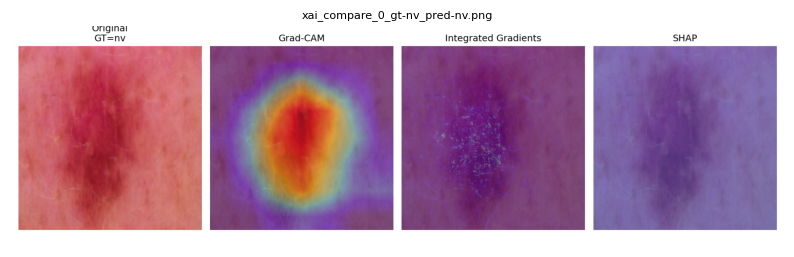

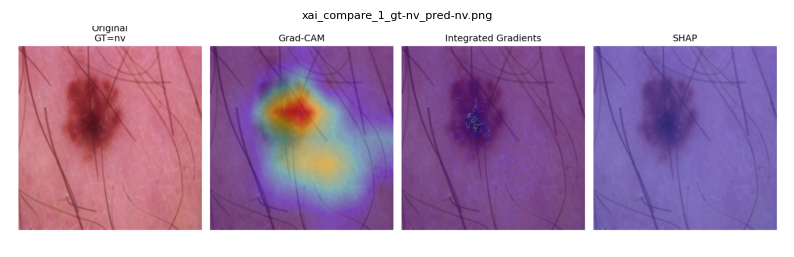

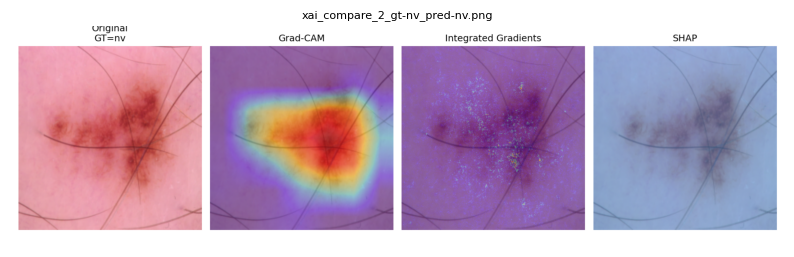

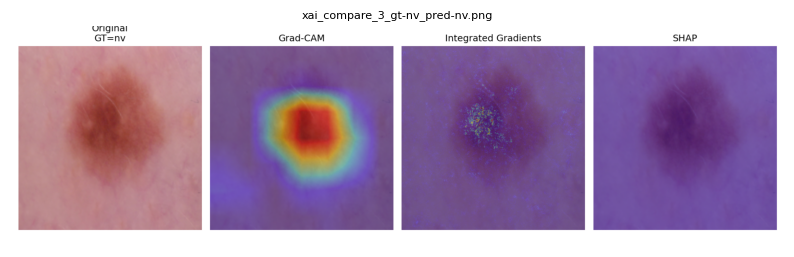

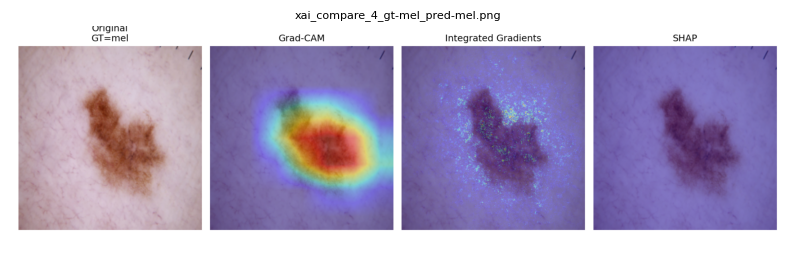

In [64]:
import glob
from matplotlib.image import imread
import matplotlib.pyplot as plt

paths = sorted(glob.glob("/content/outputs/xai_compare/xai_compare_*.png"))

for p in paths:
    img = imread(p)
    plt.figure(figsize=(10,3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(p.split("/")[-1], fontsize=8)
    plt.show()
